In [ ]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes

import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')

from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

from pipeline.obstacle_avoidance_processing import AvoidanceProcessing

In [ ]:
light = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\oa_df_051024.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\recordings\data_h5\dark_oa_df_051024.h5")
dark = dark[dark.task == 'oadark']

G8CK = light[light['animal'].isin(['G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN', 'G8CKLN'])]
G8CK1 = light[light['animal'].isin(['G8CK1RT','G8CK1LT', 'G8CK1TT', 'G8CK1LN'])]

In [ ]:
light = pd.read_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5')

In [ ]:
G8CK1.date.unique()

In [ ]:
G8CK.date.unique()

In [ ]:
G8CK_oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_oa.json",'blank')
G8CK_oa_session.gather_session_df('obstacle',6)
G8CK_oa_df = G8CK_oa_session.df
df_tortuosity(G8CK_oa_df)
G8CK_oa_df = assign_date_index(G8CK_oa_df)

In [ ]:
long,_,_ = create_df_by_type(G8CK_oa_df)

In [ ]:
G8CK1_oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_oa.json",'blank')
G8CK1_oa_session.gather_session_df('obstacle',6)
G8CK1_oa_df = G8CK1_oa_session.df
df_tortuosity(G8CK1_oa_df)
G8CK1_oa_df = assign_date_index(G8CK1_oa_df)

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\J701\oa_J701.json','blank')
oa_session.gather_session_df('obstacle',6)
J701_df = oa_session.df

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\J701\oa_J701.json','blank')
oa_session.gather_session_df('obstacle',6)
J701_df = oa_session.df

In [ ]:
oa_session = plot_oa(r"D:\obstacle_avoidance\metadata\J701_704\J704_oadark.json",'blank')
oa_session.gather_session_df('obstacle',6)
J704_df = oa_session.df

In [ ]:
oa_session = plot_oa(r'D:\obstacle_avoidance\metadata\SFN\J701_training.json','blank')
oa_session.trial_min_df(training_ses=True)
J701_train_trialpermin_df = oa_session.trialpermin_df

In [ ]:
oa_session = plot_oa(r'd:\obstacle_avoidance\metadata\SFN\G8CK_train.json','blank')
oa_session.trial_min_df(training_ses=True)
G8CK_train_trialpermin_df = oa_session.trialpermin_df

In [ ]:
G8CK1_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_train.json",'blank')
G8CK1_train.trial_min_df(training_ses=True)
G8CK1_train_trialpermin_df = G8CK1_train.trialpermin_df

G8CK1_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_oa.json",'blank')
G8CK1_oa.gather_session_df('obstacle',6)
G8CK1_oa_df = G8CK1_oa.df
G8CK1_oa_df = assign_date_index(G8CK1_oa_df)
df_tortuosity(G8CK1_oa_df)
G8CK1_oa.trial_min_df(training_ses=False)
G8CK1_oa_trialpermin_df = G8CK1_oa.trialpermin_df


In [ ]:
G8CK1_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK1_train.json",'blank')
G8CK1_train.gather_session_df('non_obstalce',6)
G8CK1_train_df = G8CK1_train.df
df_tortuosity(G8CK1_train_df)
G8CK1_train_df = assign_date_index(G8CK1_train_df,train=True)

In [ ]:
G8CK_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_train.json",'blank')
G8CK_train.trial_min_df(training_ses=True)
G8CK_train_trialpermin_df = G8CK_train.trialpermin_df

G8CK_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_oa.json",'blank')
G8CK_oa.gather_session_df('obstacle',6)
G8CK_oa_df = G8CK_oa.df
G8CK_oa_df = assign_date_index(G8CK_oa_df)
df_tortuosity(G8CK_oa_df)
G8CK_oa.trial_min_df(training_ses=False)
G8CK_oa_trialpermin_df = G8CK_oa.trialpermin_df

In [ ]:
G8CK_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\G8CK_train.json",'blank')
G8CK_train.gather_session_df('non_obstalce',6)
G8CK_train_df = G8CK_train.df
df_tortuosity(G8CK_train_df)
G8CK_train_df = assign_date_index(G8CK_train_df,train=True)

In [ ]:
J701_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_train.json",'blank')
J701_train.trial_min_df(training_ses=True)
J701_train_trialpermin_df = J701_train.trialpermin_df

J701_oa= plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_oa.json",'blank')
J701_oa.gather_session_df('obstacle',6)
J701_oa_df = J701_oa.df
J701_oa_df = assign_date_index(J701_oa_df)
df_tortuosity(J701_oa_df)
J701_oa.trial_min_df(training_ses=False)
J701_oa_trialpermin_df = J701_oa.trialpermin_df

In [ ]:
J701_train = plot_oa(r"D:\obstacle_avoidance\metadata\SFN\J701_train.json",'blank')
J701_train.gather_session_df('non_obstalce',6)
J701_train_df = J701_train.df
df_tortuosity(J701_train_df)
J701_train_df = assign_date_index(J701_train_df,train=True)

In [801]:
light_train = pd.concat([G8CK1_train_df,G8CK_train_df,J701_train_df])
#light_train = light_train.drop(columns='level_0')
light_train= light_train.reset_index()
light_train = light_train[light_train.date_index >= -4]
light_train = light_train.drop(light_train.filter(regex='likelihood').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='resample').columns,axis = 1)
light_train.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_train.h5','w')

In [800]:
light_train = light_train.drop(light_train.filter(regex='likelihood').columns,axis = 1)
light_train = light_train.drop(light_train.filter(regex='resample').columns,axis = 1)

In [803]:
joint = pd.concat([light_train,light])
joint = joint.drop(columns='level_0')
joint= joint.reset_index()

<AxesSubplot: xlabel='date_index', ylabel='time'>

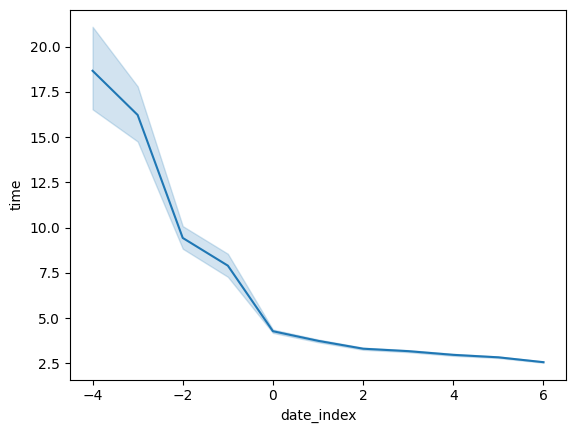

In [805]:
sns.lineplot(data =joint,x = 'date_index',y='time' )

In [ ]:
light = pd.concat([J701_oa_df,G8CK1_oa_df,G8CK_oa_df])
light = light.drop(columns='level_0')
light= light.reset_index()
light = light[(light.date_index <=6)]
sns.barplot(data =light,x = 'date_index',y='linearity' )
plt.ylim(.7,1)


In [ ]:
test = light[light.linearity>.8].sample(1)

In [ ]:
test.obstacle_cluster.to_numpy()[0]

In [ ]:
test = G8CK1_train_df[G8CK1_train_df.linearity<.7].sample(1)
fig,ax = plt.subplots()
plot_arena(test,ax)
#plot_orginal_obstacle(test,ax,test.obstacle_cluster.to_numpy()[0])
for ind,row in test.iterrows():
    ax.plot(row.ts_nose_x_cm,row.ts_nose_y_cm)

In [ ]:
light_trial_permin = pd.concat([J701_oa_trialpermin_df,J701_train_trialpermin_df,G8CK_oa_trialpermin_df,G8CK_train_trialpermin_df,G8CK1_oa_trialpermin_df,G8CK1_train_trialpermin_df])
light_trial_permin = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
sns.lineplot(data =light_trial_permin,x = 'date_index',y='trials' ,errorbar='se',err_style='bars')

In [ ]:

from matplotlib.gridspec import GridSpec

In [790]:
light_trial_permin = pd.concat([J701_oa_trialpermin_df,J701_train_trialpermin_df,G8CK_oa_trialpermin_df,G8CK_train_trialpermin_df,G8CK1_oa_trialpermin_df,G8CK1_train_trialpermin_df])
light_trial_permin.to_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5", 'w')

In [ ]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [ ]:
light_trial_permin[(light_trial_permin.date_index == 0.0 ) 

In [ ]:
light_trial_permin

In [ ]:
light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)]

<AxesSubplot: xlabel='Days', ylabel=' '>

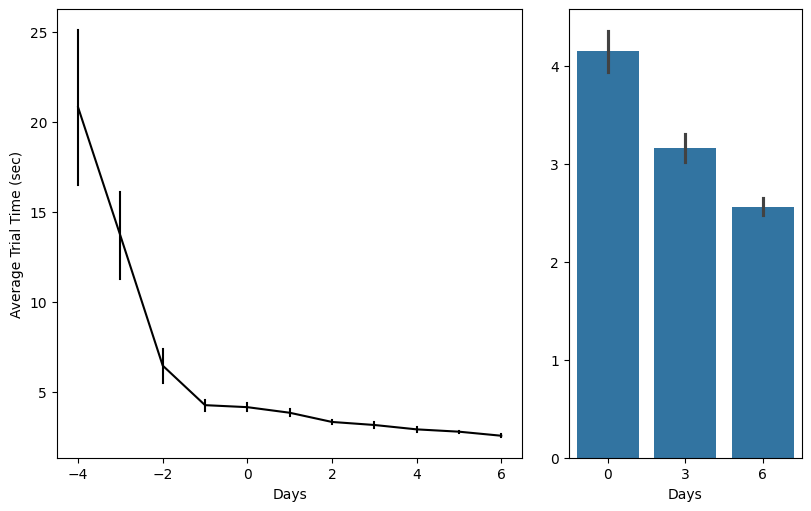

In [806]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time',errorbar = 'se')


<AxesSubplot: xlabel='Days', ylabel=' '>

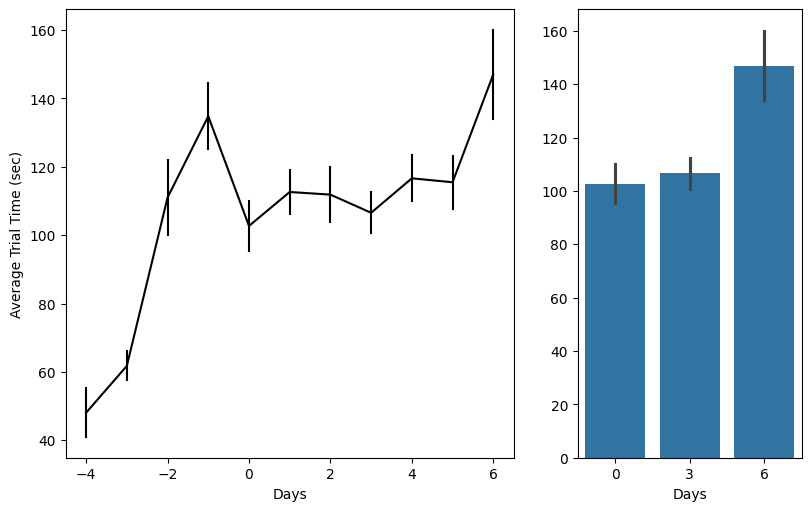

In [807]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trials' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trials',errorbar = 'se')


<AxesSubplot: xlabel='Days', ylabel=' '>

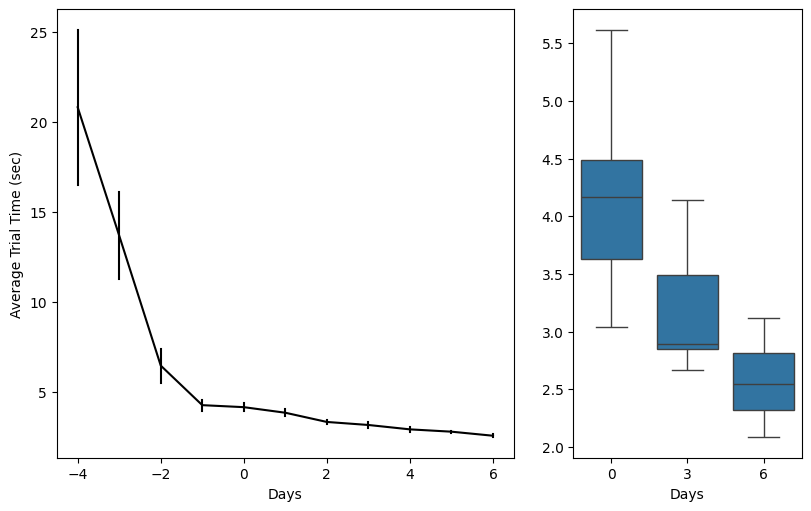

In [808]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Average Trial Time (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.boxplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time')


In [ ]:
from scipy.stats import f_oneway
from scipy.stats import tukey_hsd
f_oneway(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())
res = tukey_hsd(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())

In [ ]:
f_oneway(line[line.date_index==0].trial_time.to_numpy(),line[line.date_index==3].trial_time.to_numpy(),line[line.date_index==6].trial_time.to_numpy())

In [ ]:
print(res)

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import bootstrap

In [ ]:
tukey = pairwise_tukeyhsd(endog = bar['trialpermin'],groups=bar['date_index'])
print(tukey)

In [ ]:
res = bootstrap(data, np.std, confidence_level=0.9,
                random_state=rng)

In [ ]:
tukey = pairwise_tukeyhsd(endog = line['trialpermin'],groups=line['date_index'])
print(tukey)

<AxesSubplot: xlabel='Days', ylabel=' '>

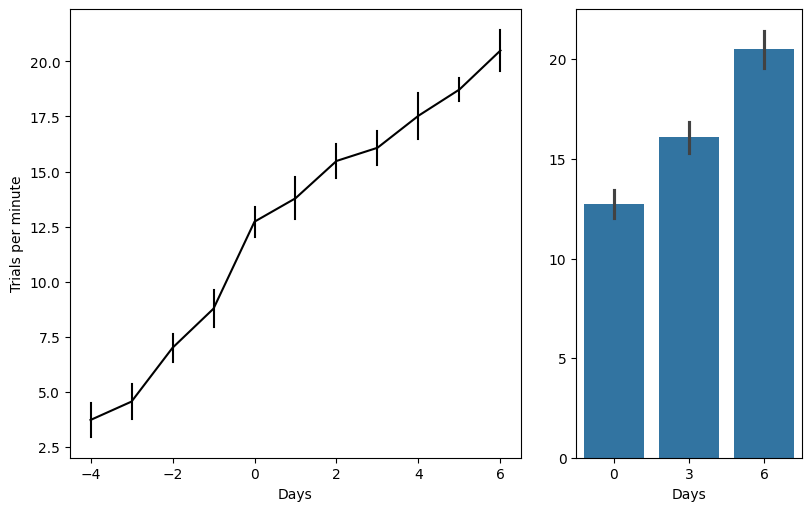

In [809]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('Days')
ax1.set_ylabel('Trials per minute')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('Days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trialpermin' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trialpermin',errorbar = 'se')

In [ ]:
tukey = pairwise_tukeyhsd(endog = line['trialpermin'],groups=line['date_index'])
print(tukey)

In [ ]:
distance_calcs(light)
deveation(light)
heading_calcs(light)

In [ ]:
lateral_error(light)

In [791]:
light.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5','w')

In [ ]:
light.lateral_error

In [ ]:
def edge_outliers(array,thresh):
    "take out edege outliers in interpolations"
    diff = np.diff(array)
    if np.abs(diff[-1]) > thresh:
        array[-1] = array[-2]
    else:
        array = array
    return array

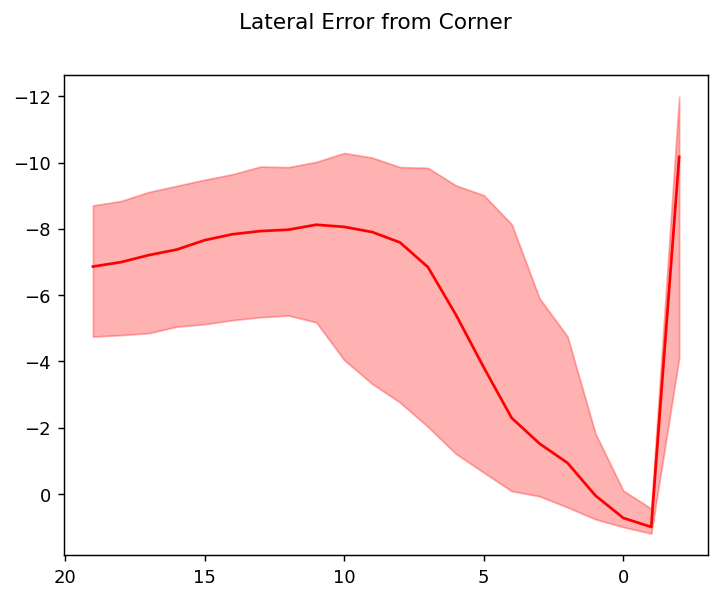

In [811]:

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long[long.date_index==1]
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)




In [ ]:
angle_mean

In [ ]:
angle_mean[-1] = angle_mean[-2]

In [ ]:
edge_outliers(angle_mean,2)

In [ ]:
np.diff(angle_mean)

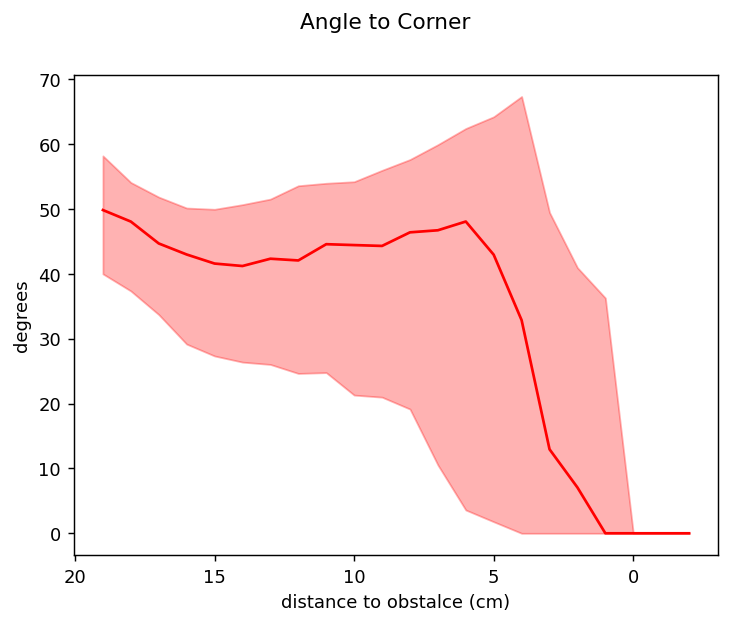

In [812]:
df = long[long.date_index==0]
df = drop_nans_in_columns(df,'ts_zero_out_angle_to_corner')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

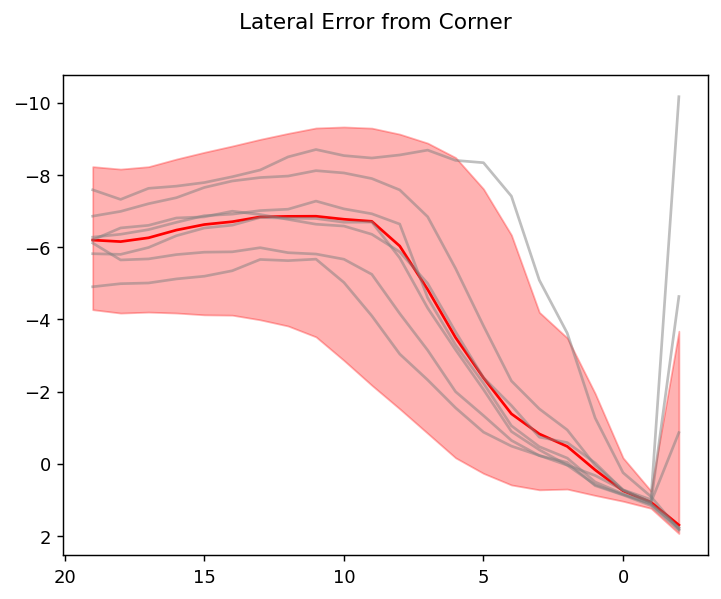

In [813]:

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

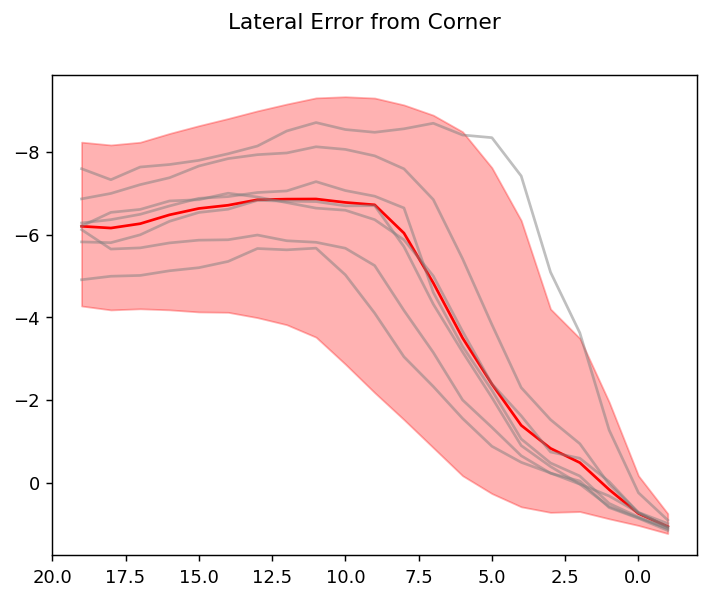

In [814]:

xnew =  np.arange(-1, 20, 1) 
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error from Corner')
ax.invert_xaxis()
ax.invert_yaxis()
#ax.set_ylim((0,-10))
df = long
#data = drop_nans_in_columns(data,'obstacle_devations')
df = drop_nans_in_columns(df,'lateral_error')



rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)

ax.fill_between(xnew, edge_outliers(q1,1.5), edge_outliers(q3,1.5), color='r', alpha=0.3, label='IQR')
#symmetrize_y_axis(ax)

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)
    angle_mean = edge_outliers(angle_mean,1.5)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    #median, q1, q3, iqr = calculate_quartiles(angle_array)

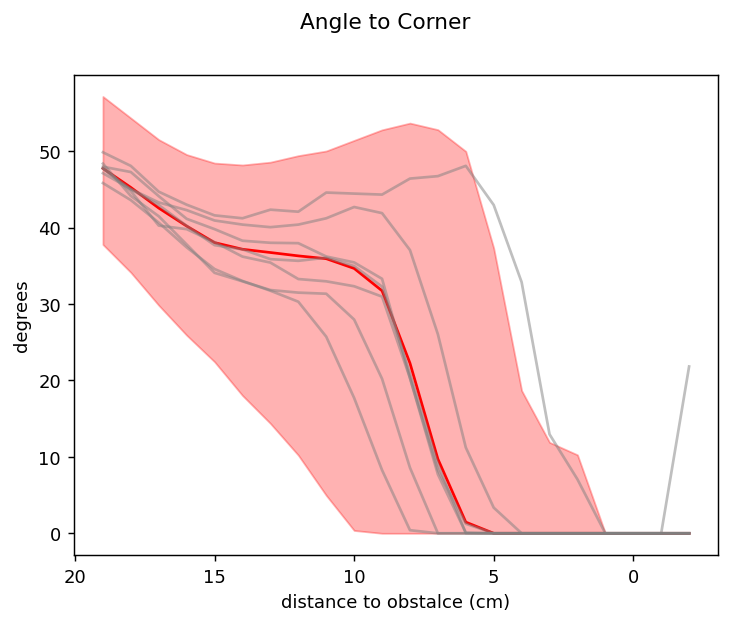

In [815]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['date_index']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    #median, q1, q3, iqr = calculate_quartiles(angle_array)

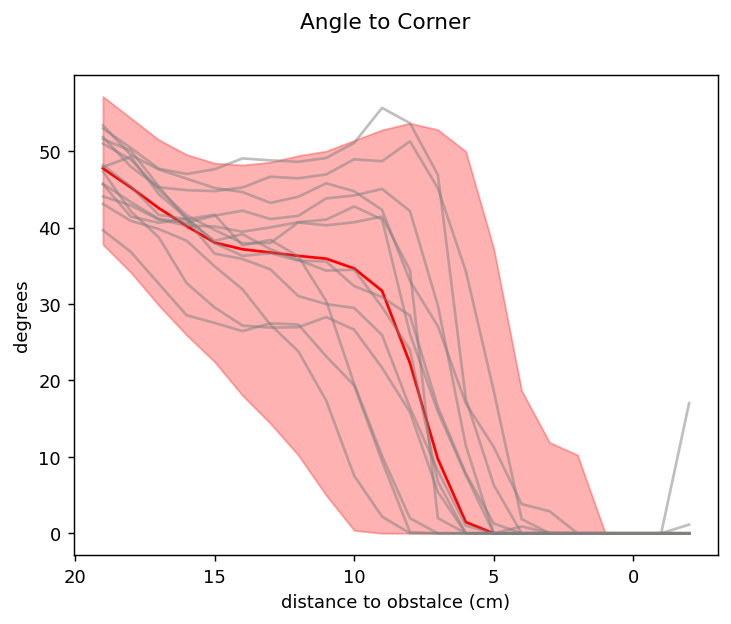

In [816]:
df = long
df = drop_nans_in_columns(df,'obstacle_ind')
fig,ax = plt.subplots(dpi = 130)
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
fig.suptitle('Angle to Corner')
#ax.invert_xaxis()
#ax.invert_xaxis()

xnew =  np.arange(-2, 20, 1) 
xnew= np.flip(xnew)

#xnew= np.flip(xnew)

rows = df.shape[0]
angle_array = np.empty([rows,xnew.size])
angle_array[:] =np.nan


for i,row in enumerate(df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
    x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
    y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
    interpolater = interp1d(x,y,bounds_error=False)
    ynew = interpolater(xnew)
    angle_array[i] = ynew
angle_mean = np.nanmedian(angle_array,axis = 0)
ax.invert_xaxis()
ax.plot(xnew,angle_mean,c='r')
median, q1, q3, iqr = calculate_quartiles(angle_array)
ax.fill_between(xnew, q1, q3, color='r', alpha=0.3, label='IQR')

for ani,ani_df in df.groupby(['animal']):
    rows = ani_df.shape[0]
    angle_array = np.empty([rows,xnew.size])
    angle_array[:] =np.nan
    for i,row in enumerate(ani_df.iterrows()):
    #first_zero = np.where( row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)==0)[0].min()
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        interpolater = interp1d(x,y,bounds_error=False)
        ynew = interpolater(xnew)
        angle_array[i] = ynew
    angle_mean = np.nanmedian(angle_array,axis = 0)
    angle_median= np.nanmedian(angle_array,axis = 0)

    ax.plot(xnew,angle_mean,color = 'grey',alpha = .5)
    median, q1, q3, iqr = calculate_quartiles(angle_array)

In [835]:
df_tortuosity(li)

In [ ]:
deeplabcut.extract_frames(path_config_file, 'automatic', 'kmeans', crop = False, userfeedback = False)

Config file read successfully.
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 908.62  seconds.
Extracting and downsampling... 54517  frames from the video.


54517it [03:13, 282.03it/s]


Kmeans clustering ... (this might take a while)


c:\Users\nlab\anaconda3\envs\oa\lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)
c:\Users\nlab\anaconda3\envs\oa\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 515.05  seconds.
Extracting and downsampling... 30903  frames from the video.


...

Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 560.02  seconds.
Extracting and downsampling... 33601  frames from the video.


33601it [01:46, 315.59it/s]
c:\Users\nlab\anaconda3\envs\oa\lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


Kmeans clustering ... (this might take a while)


c:\Users\nlab\anaconda3\envs\oa\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).


In [842]:
row.ts_nose_x_cm

array([11.678553011364848, 11.509722269291473, 11.327788526395985, ...,
       nan, nan, nan], dtype=object)

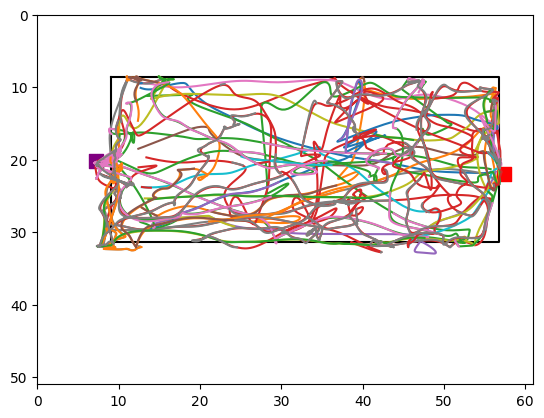

In [861]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='J701NN')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [862]:
light_train.time

201     3.350000
202     2.916667
203     2.916667
204     3.583333
205     3.900000
          ...   
5030         NaN
5031         NaN
5032         NaN
5033         NaN
5034         NaN
Name: time, Length: 4834, dtype: float64

In [871]:
train_J701RT.time

4242     4.083333
4244     4.733333
4246     4.316667
4249     3.666667
4251    10.766667
          ...    
4498          NaN
4500          NaN
4502          NaN
4504          NaN
4506          NaN
Name: time, Length: 132, dtype: float64

In [957]:
train_J701RT.date.unique()

array(['051223'], dtype=object)

In [962]:
train_G8CK1RT = pd.read_hdf(r"D:\obstacle_avoidance\recordings\051123\G8CK1RT\oa\non_obstacleG8CK1RT_051123_oa.h5")

In [966]:
train_G8CK1RT[train_G8CK1RT.odd=='right']

,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,nose_likelihood,leftear_x,leftear_y,leftear_likelihood,...,ts_spine_x_cm,ts_spine_y_cm,ts_midspine_x_cm,ts_midspine_y_cm,ts_tailbase_x,ts_tailbase_y,ts_tailbase_x_cm,ts_tailbase_y_cm,dist,time
1,47385.406643,47393.861555,"[47385.422464, 47385.438924, 47385.455488, 473...","[[1432, 1433, 1434, 1435, 1436, 1437, 1438, 14...","[680.7618002514187, 680.7560995479967, 680.746...","[284.2336038174256, 284.42001484476043, 284.76...","[0.8122714757919312, 0.8892142176628113, 0.804...","[685.017243627769, 684.978021853236, 684.90640...","[266.28076076766655, 266.3091966598274, 266.37...","[0.9985841512680054, 0.9986774325370789, 0.999...",...,"[56.34876101513008, 56.160871803291464, 56.109...","[31.749116862626256, 31.87834007680234, 31.692...","[57.31181982685095, 57.197844416378814, 57.125...","[30.032435816820726, 30.027565322053874, 30.08...","[665.602294921875, 665.6513671875, 666.1672363...","[320.6836853027344, 320.89166259765625, 320.73...","[57.826734790743046, 57.83099813074582, 57.875...","[27.860616712410728, 27.878685532136412, 27.86...",48.683568,8.433333
3,47399.141734,47412.524505,"[47399.144371, 47399.160153, 47399.176908, 473...","[[2255, 2256, 2257, 2258, 2259, 2260, 2261, 22...","[682.3619995117188, 682.3619995117188, 682.361...","[257.7893981933594, 257.7893981933594, 257.789...","[0.21795544028282166, 0.24465060234069824, 0.2...","[685.0060827151683, 685.0484767050507, 685.128...","[264.7566637827797, 264.76910868736394, 264.78...","[0.9966161847114563, 0.9942594766616821, 0.995...",...,"[56.59950267603942, 56.58539759593074, 56.4740...","[14.304492004377826, 14.221808926233257, 14.27...","[57.12647589262593, 57.01178992548667, 56.9859...","[15.403846455310473, 15.374482966174462, 15.30...","[655.979732390373, 654.6558444115424, 653.3319...","[193.23424554640246, 191.30887086929815, 189.3...","[56.990738016450344, 56.87572020532114, 56.760...","[16.787961151805668, 16.620686892574344, 16.45...",108.231315,13.366667
5,47418.193817,47425.243532,"[47418.200512, 47418.216755, 47418.233497, 474...","[[3398, 3399, 3400, 3401, 3402, 3403, 3404, 34...","[685.6491088867188, 685.6491088867188, 685.649...","[261.90057373046875, 261.90057373046875, 261.9...","[0.1703728437423706, 0.16331949830055237, 0.14...","[683.8334133551716, 683.7787510108759, 683.676...","[265.2771148752834, 265.33648607313086, 265.44...","[0.9951198101043701, 0.9955663084983826, 0.997...",...,"[56.80360212467963, 56.597933088177705, 56.252...","[15.157940821866962, 15.047117843772499, 14.96...","[57.310653241278054, 57.251327062234495, 57.18...","[15.890523420011322, 15.75786938371858, 15.807...","[656.3543701171875, 657.366455078125, 657.8471...","[213.357421875, 212.9574432373047, 212.8196716...","[57.02328609604141, 57.11121483226775, 57.1529...","[18.536238748771815, 18.501489081019116, 18.48...",45.975786,7.033333
7,47436.316006,47442.153305,"[47436.322726, 47436.340966, 47436.35639, 4743...","[[4485, 4486, 4487, 4488, 4489, 4490, 4491, 44...","[678.52978515625, 678.52978515625, 678.5297851...","[298.88934326171875, 298.88934326171875, 298.8...","[0.08497074991464615, 0.06943661719560623, 0.0...","[680.5719371434103, 680.7454413142177, 681.058...","[265.53588646616606, 265.4751751982419, 265.36...","[0.9991462230682373, 0.9990150928497314, 0.998...",...,"[55.94141054372087, 55.77123752460522, 55.5994...","[31.536005540435415, 31.40418137069794, 31.295...","[56.45638383689162, 56.53079608845742, 56.4816...","[29.844419341101432, 29.901155169906986, 29.88...","[640.346923828125, 643.2164916992188, 646.7897...","[317.79876708984375, 317.80078125, 318.7319030...","[55.6325782239429, 55.8818828635329, 56.192327...","[27.609978453404437, 27.61015344124037, 27.691...",45.546771,5.816667
9,47447.007539,47454.352140,"[47447.010828, 47447.026752, 47447.043392, 474...","[[5126, 5127, 5128, 5129, 5130, 5131, 5132, 51...","[684.8007202148438, 684.8007202148438, 684.800...","[258.036407470703

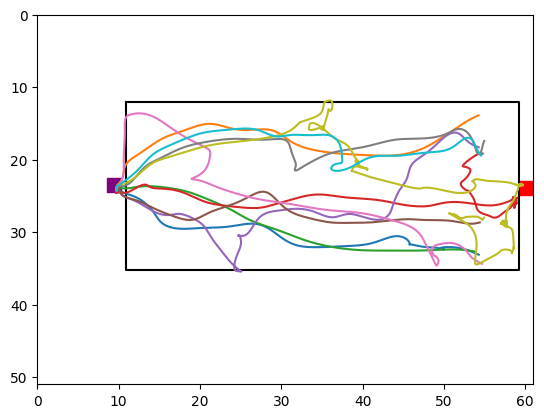

In [967]:

fig,ax = plt.subplots()
plot_arena(train_G8CK1RT,ax)
for ind, row in train_G8CK1RT[train_G8CK1RT.odd=='right'].sample(10).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

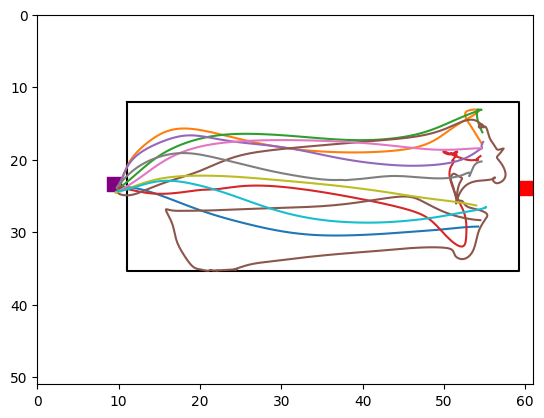

In [970]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1RT')&(light_train.odd=='right')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.sample(10).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

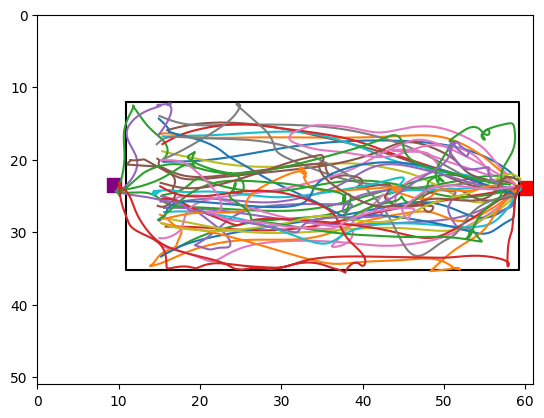

In [951]:
train_J701RT = light_train[(light_train.date_index==-4) &(light_train.animal=='G8CK1RT')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

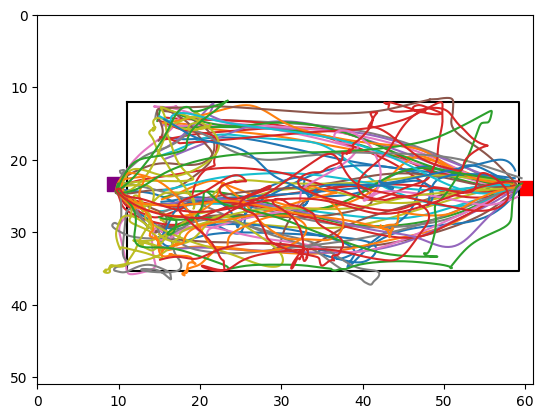

In [954]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1RT')&(light_train.odd=='left')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

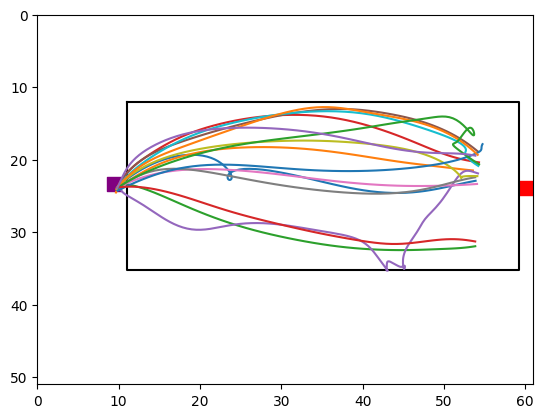

In [947]:
train_J701RT = light_train[(light_train.date_index==-1) &(light_train.animal=='G8CK1LN')&(light_train.odd=='right')]
fig,ax = plt.subplots()
plot_arena(train_J701RT,ax)
for ind, row in train_J701RT.sample(15).iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

In [ ]:
def  trail_min_df(self):
        # list data path files
        data_path = Path(self.path).expanduser()
        # find date
        hf_list = []
        df =pd.DataFrame()
        for date in self.dates_list:
            use_animals = [k for k,v in self.metadata[date].items()]
            for ani in use_animals:
                for task in os.listdir(data_path / date / ani):
                    h5_paths=[str(i) for i in list((data_path / date / ani/ task).rglob('*.h5'))]
                    raw_h5 = [i for i in h5_paths if 'test' in i]
                    hf_list.append(raw_h5)
        hf_list = list(itertools.chain(*hf_list))
        for h5 in hf_list:
            data = pd.read_hdf(h5)
            df=df.append(data,ignore_index=False)
        self.df=df
        self.df['orginal_index'] = self.df.index
        self.df =self.df.reset_index()

        dictists = {key: [] for key in ['animal','date','date_index','trialpermin','task']}
        for date, date_df in self.df .groupby(['date_index']):
            for ani, ani_df in date_df.groupby(['animal']):
                for task,task_df in ani_df.groupby('task'):
                    dictists['animal'].append(ani)
                    dictists['date_index'].append(date)
                    trialpermin = (len(task_df))/(task_df.len.sum()/60/60)
                    dictists['trialpermin'].append(trialpermin)
                    dictists['task'].append(task_df.task.unique()[0])
        trialpermin_df = pd.DataFrame.from_dict(dictists)



       

In [ ]:
def find_consecutive_repeats2(series):
    result = []
    count = 1
    for i in range(1, len(series)):
        if series[i] == series[i-1]:
            count += 1
        else:
            if count >= 3:
                result.append((i-count, series[i-1]))
            count = 1
    if count >= 3:
        result.append((len(series)-count, series[len(series)-1]))
    return result

In [ ]:
def find_consecutive_repeats(series):

    """
    finds consective repeats in a pd.series
    Used to find trials that have repeat of the same  obstacle location
    """
    consecutive_repeats = []
    count = 1
    prev_value = None

    for index, value in series.iteritems():
        if value == prev_value:
            count += 1
        else:
            if count > 3:
                count = 1
                prev_value = value
            
            count = 1
            prev_value = value

        if count >= 3:
            consecutive_repeats.append((index - count+1, index, value,count))
    
 
    #for count,row in enumerate(consecutive_repeats):
    #    if consecutive_repeats[count][-1] != 3:
    #        del consecutive_repeats[count]
    

    return consecutive_repeats

def create_consective_df_new(df):
        """get df from data of groups of 3 trials that are consecutive """
        con_df = pd.DataFrame()
        copy = df.copy(deep=True)
        copy = copy.reset_index(drop=True)
        for animal,animal_frame in copy.groupby('animal'):
            for date, date_frame in animal_frame.groupby('date'):
                repeats_list = find_consecutive_repeats(date_frame['obstacle_cluster'])
                for i in range(len(repeats_list)):
                    check = date_frame.loc[repeats_list[i][0]:repeats_list[i][1]]
                    #print(np.diff(check['index'].to_numpy()).sum())
                    if np.diff(check['index'].to_numpy()).sum()==2:
                        trial_df = pd.DataFrame()
                        trial_df = trial_df.append(date_frame.loc[repeats_list[i][0]:repeats_list[i][1]])
                        trial_df['consective_inds'] = str(list(range(repeats_list[i][0], repeats_list[i][1]+1)))
                        trial_df['consective_type'] = [1,2,3]
                        con_df = con_df.append(trial_df) 
                    else:
                        continue
                       
        return con_df

In [ ]:
def create_consective_df_new(df):
        """get df from data of groups larger than 3 trials that are consecutive """
        con_df = pd.DataFrame()
        copy = df.copy(deep=True)
        copy = copy.reset_index(drop=True)
        for animal,animal_frame in copy.groupby('animal'):
            for date, date_frame in animal_frame.groupby('date'):
                repeats_list = find_consecutive_repeats(date_frame['obstacle_cluster'])
                for i in range(len(repeats_list)):
                    check = date_frame.loc[repeats_list[i][0]:repeats_list[i][1]]
                    #print(np.diff(check['index'].to_numpy()).sum())
                    
                    trial_df = pd.DataFrame()
                    trial_df = trial_df.append(date_frame.loc[repeats_list[i][0]:repeats_list[i][1]])
                    trial_df['consective_inds'] = str(list(range(repeats_list[i][0], repeats_list[i][1]+1)))
                    trial_df['consective_type'] = list(range( (repeats_list[i][1]+1) - (repeats_list[i][0])))
                    con_df = con_df.append(trial_df) 
                    
                       
        return con_df

In [ ]:
def assign_date_index(df):
    '''assign dates with index 0 == first day'''
    df = df.copy(deep = True)
    date_list = df.date.unique().tolist() 
    date_list = sorted([int(x) for x in date_list])
    date_list = list(map(str, date_list))
    date_list = ['0'+ date for date in date_list]
    index_list = list(range((len(date_list))))
    date_index_dict = dict(zip(date_list,index_list))
    for ind,row in df.iterrows():
        df.at[ind,'date_index']= int(date_index_dict.get(row.date))

    return df




In [ ]:
fig,ax = plt.subplots()
sns.lineplot(data =  light, estimator='median',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light.groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

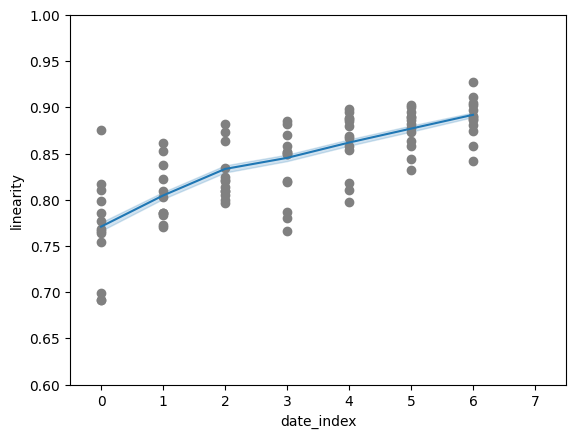

In [817]:
fig,ax = plt.subplots()
sns.lineplot(data =  light[light['tortuosity']<5], estimator='median',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light[light['tortuosity']<5].groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

In [ ]:
fig,ax = plt.subplots()
sns.lineplot(data =  light[light['tortuosity']<5], estimator='mean',errorbar = 'se' ,x = 'date_index',y = 'linearity')
plt.xlim(-.5,7.5)
plt.ylim(.6,1)
for date, date_df in light[light['tortuosity']<5].groupby(['date_index']):
    for ani, animal_df in date_df.groupby(['animal']):
        ax.scatter(date,animal_df.linearity.median(),color = 'grey')

In [840]:
from scipy.ndimage import gaussian_filter

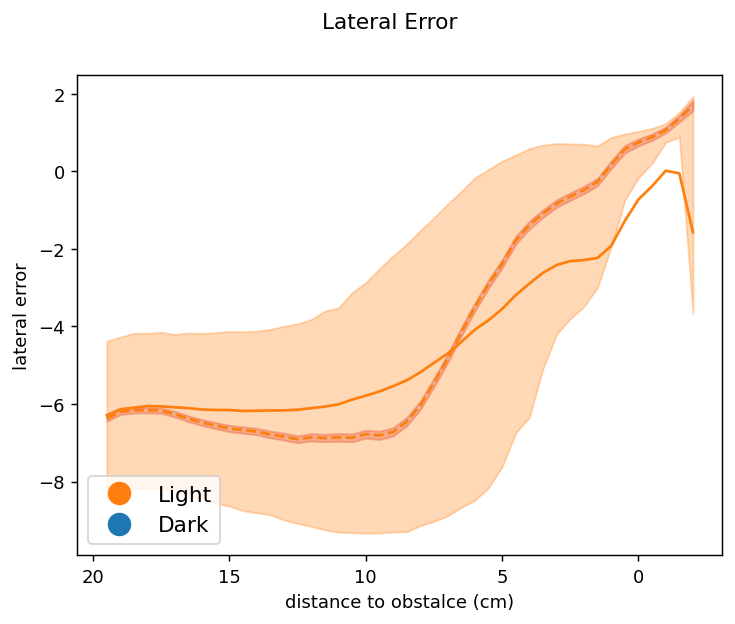

In [820]:

xnew =  np.arange(-2, 20, .5)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = long[long.task =='oa']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
    std = np.nanstd(angle_array, axis=0)
    std_error = []
    samplesqrt =np.sqrt(angle_array.shape[0])
    for i in std:
        std_error.append(i/samplesqrt)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, date_angle_median-std_error, date_angle_median + std_error, color='tab:red', alpha=0.3, label='IQR')
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:
test = np.nanstd(angle_array, axis=0)
std_error = []
samplesqrt =np.sqrt(angle_array.shape[0])
for i in test:
    std_error.append(i/samplesqrt)

In [ ]:
angle_array.shape[0]

In [ ]:
angle_array.shape[0]

In [ ]:
np.sqrt(angle_array.shape[0])

In [ ]:
angle_array[:,0]

In [ ]:
sem(angle_array[:,0],nan_policy='omit')

In [ ]:
from scipy.stats import sem

In [ ]:
angle_array.shape

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = J701_df[J701_df.task =='oa']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = dark_long[dark_long.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Lateral Error')
ax.invert_xaxis()
data = dark[dark.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['lateral_error'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('lateral error')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = dark_long[dark_long.task =='oadark']
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

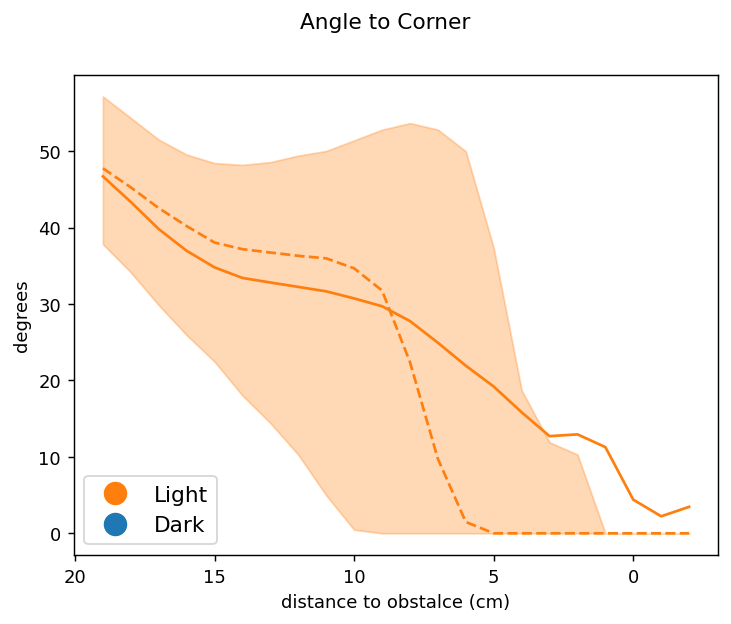

In [821]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = long
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

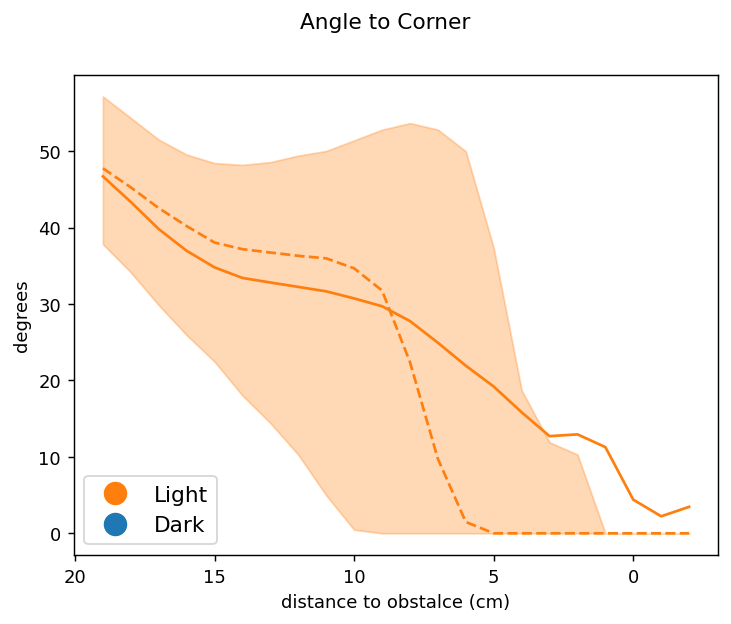

In [826]:

xnew =  np.arange(-2, 20, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = long
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

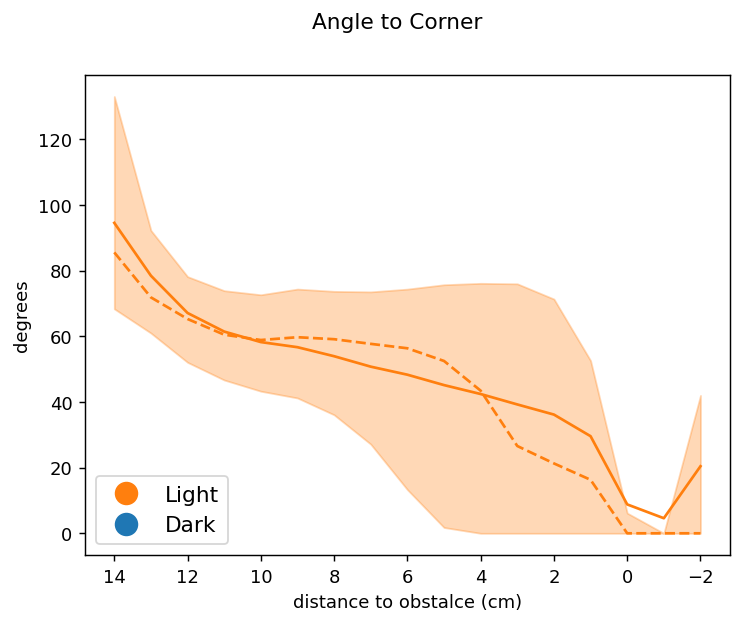

In [831]:

xnew =  np.arange(-2, 15, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(dpi = 130)
fig.suptitle('Angle to Corner')
ax.invert_xaxis()
data = short
data = drop_nans_in_columns(data,'obstacle_devations')
data = drop_nans_in_columns(data,'lateral_error')
#data = drop_nans_in_columns(data,'speed')
for date,date_df in  data.groupby(['task']):
  
   
    rows = date_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(date_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            #x = resample(x,20)
            #y = resample(np.flip(np.unique(y)),len(x))
            #y = resample(y,len(x))
            interpolater = interp1d(x,y,bounds_error=False)
            #interpolater = splrep(row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])],row[1]['ts_zero_out_angle_to_corner'])
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    date_angle_mean = np.nanmean(angle_array,axis = 0)
    date_angle_median= np.nanmedian(angle_array,axis = 0)

        

    median, q1, q3, iqr = calculate_quartiles(angle_array)
 
    if date == 'oa':
        light_array = angle_array
        ax.fill_between(xnew, q1, q3, color='tab:orange', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:orange',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:orange',alpha = 1)
    else:
        ax.fill_between(xnew, q1, q3, color='tab:blue', alpha=0.3, label='IQR')
        ax.plot(xnew,date_angle_mean,c = 'tab:blue',alpha = 1)
        ax.plot(xnew,date_angle_median,'--',c = 'tab:blue',alpha = 1)
        
ax.set_ylabel('degrees')
ax.set_xlabel('distance to obstalce (cm)')
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:orange','tab:blue']]
ax.legend(markers, ['Light','Dark'], numpoints=1,loc = 'lower left',fontsize=12)

In [ ]:
from scipy.stats import gaussian_kde
def normalize_arrays(array):
    min_max_scaler = p.MinMaxScaler() 
    norm_array_of_arrays = min_max_scaler.fit_transform(array.reshape(-1, 1)).flatten() 
    return norm_array_of_arrays
from sklearn import preprocessing as p 